# Strategy B — hierarchical classification

This notebook implements the classification-only inverse-design strategy. The first stage identifies the material family (NA, MW, or OW); the second stage classifies the additive percentage for MW or OW. The input descriptors are the flexural modulus $E_f$, flexural strength $\sigma_r$, and strain at break $\varepsilon_r$.


In [1]:
%pip install -q imbalanced-learn openpyxl


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

# Consistent plotting style for publication-ready figures.
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": [
        "Times New Roman",
        "STIXGeneral",
        "DejaVu Serif"
    ],
    "mathtext.fontset": "stix",
    "axes.labelsize": 14,
    "axes.titlesize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "figure.titlesize": 14,
    "axes.linewidth": 0.8,
})

FIG_DIR = Path("figures_pdf")
FIG_DIR.mkdir(exist_ok=True)


def save_pdf(fig, filename):
    """Save a Matplotlib figure as a vector PDF."""
    fig.savefig(
        FIG_DIR / f"{filename}.pdf",
        format="pdf",
        bbox_inches="tight",
        pad_inches=0.02,
    )


from sklearn.base import clone

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
    learning_curve,
)

from sklearn.preprocessing import (
    StandardScaler,
    LabelEncoder,
)

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

In [3]:
# Locate the public dataset or request an upload in Google Colab.

from pathlib import Path

candidate_paths = [
    Path("../dataset/dataset_additives.xlsx"),
    Path("dataset/dataset_additives.xlsx"),
    Path("dataset_additives.xlsx"),
    Path("/content/dataset_additives.xlsx"),
]

dataset_path = next(
    (
        path
        for path in candidate_paths
        if path.exists()
    ),
    None
)

if dataset_path is None:

    try:
        from google.colab import files

    except ImportError as exc:
        raise FileNotFoundError(
            "dataset_additives.xlsx was not found. "
            "Place it beside the notebook or inside "
            "a dataset/ subdirectory."
        ) from exc

    print(
        "Dataset not found. "
        "Please upload dataset_additives.xlsx."
    )

    uploaded = files.upload()

    if not uploaded:
        raise FileNotFoundError(
            "No dataset was uploaded."
        )

    dataset_path = Path(
        next(iter(uploaded))
    )

print(f"Using dataset: {dataset_path}")

Dataset not found. Please upload dataset_additives.xlsx.


Saving dataset_additives (7).xlsx to dataset_additives (7).xlsx
Using dataset: dataset_additives (7).xlsx


In [4]:
# Load the five-column specimen-level dataset and assign concise internal names.
df_raw = pd.read_excel(dataset_path, keep_default_na=False)

column_map = {
    "material": "material",
    "percentage (%)": "percentage",
    "flexural_modulus (GPa)": "flexural_modulus",
    "flexural_strength_at_break (MPa)": "flexural_strength",
    "strain_at_break (%)": "strain_at_break",
}

missing_columns = [name for name in column_map if name not in df_raw.columns]
if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

df = df_raw[list(column_map)].rename(columns=column_map).copy()
numeric_columns = [
    "percentage",
    "flexural_modulus",
    "flexural_strength",
    "strain_at_break",
]
for col in numeric_columns:
    df[col] = pd.to_numeric(
        df[col].astype(str).str.replace(",", ".", regex=False),
        errors="coerce",
    )

df["material"] = df["material"].astype(str).str.strip().str.upper()

if df[numeric_columns].isna().any().any():
    raise ValueError("The required numeric columns contain missing or invalid values.")

display(df.head())
print("Dataset shape:", df.shape)
print("Samples by material:")
print(df["material"].value_counts(dropna=False))


,material,percentage,flexural_modulus,flexural_strength,strain_at_break
0,NA,0,3.74,103.95,4.18
1,NA,0,3.69,99.88,3.83
2,NA,0,3.54,103.76,4.11
3,NA,0,3.80,104.76,4.86
4,NA,0,3.95,100.34,3.86


Dataset shape: (60, 5)
Samples by material:
material
MW    30
OW    20
NA    10
Name: count, dtype: int64


In [5]:
# Mechanical descriptors used as model inputs.

FEATURES = [
    "flexural_modulus",
    "flexural_strength",
    "strain_at_break",
]

X_material = df[FEATURES].copy()
y_material = df["material"].copy()

material_encoder = LabelEncoder()
y_material_enc = material_encoder.fit_transform(
    y_material
)

print("Material mapping:")

for material_class, class_code in zip(
    material_encoder.classes_,
    material_encoder.transform(
        material_encoder.classes_
    )
):
    print(
        f"{material_class} -> {class_code}"
    )

print("\nModel input features:")
print(FEATURES)

Material mapping:
MW -> 0
NA -> 1
OW -> 2

Model input features:
['flexural_modulus', 'flexural_strength', 'strain_at_break']


In [6]:
X_train_mat, X_test_mat, y_train_mat, y_test_mat = train_test_split(
    X_material,
    y_material_enc,
    test_size=0.2,
    random_state=42,
    stratify=y_material_enc
)

print("Train shape:", X_train_mat.shape)
print("Test shape: ", X_test_mat.shape)

Train shape: (48, 3)
Test shape:  (12, 3)


In [7]:
# Material-family classification models.
# SMOTE is applied only within each training or cross-validation fold.

material_models = {
    "RandomForestClassifier": ImbPipeline([
        (
            "smote",
            SMOTE(
                random_state=42,
                k_neighbors=3
            )
        ),
        (
            "model",
            RandomForestClassifier(
                n_estimators=200,
                max_depth=5,
                min_samples_leaf=2,
                class_weight="balanced",
                random_state=42
            )
        )
    ]),

    "LogisticRegression": ImbPipeline([
        (
            "scaler",
            StandardScaler()
        ),
        (
            "smote",
            SMOTE(
                random_state=42,
                k_neighbors=3
            )
        ),
        (
            "model",
            LogisticRegression(
                max_iter=3000,
                class_weight="balanced",
                random_state=42
            )
        )
    ]),

    "SVC": ImbPipeline([
        (
            "scaler",
            StandardScaler()
        ),
        (
            "smote",
            SMOTE(
                random_state=42,
                k_neighbors=3
            )
        ),
        (
            "model",
            SVC(
                probability=True,
                class_weight="balanced",
                random_state=42
            )
        )
    ])
}

In [27]:
# Specimen-wise cross-validation for material-family classification.
#
# These results are retained as a within-domain reference because
# specimens belonging to the same formulation may occur in different
# folds. The final classifier is selected using the stricter LOFO
# results obtained in Strategy A.

cv_material = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

material_results = []

specimen_wise_best_material_name = None
specimen_wise_best_material_score = -np.inf

print(
    "=== MATERIAL CLASSIFIERS: "
    "SPECIMEN-WISE CV ON THE TRAINING SET ==="
)

for classifier_name, base_model in material_models.items():

    model = clone(base_model)

    cv_results = cross_validate(
        model,
        X_train_mat,
        y_train_mat,
        cv=cv_material,
        scoring={
            "accuracy": "accuracy",
            "balanced_accuracy":
                "balanced_accuracy",
            "f1_macro": "f1_macro",
        },
        return_train_score=True,
        n_jobs=-1,
        error_score=np.nan
    )

    row = {
        "classifier":
            classifier_name,

        "cv_train_accuracy_mean":
            np.nanmean(
                cv_results["train_accuracy"]
            ),

        "cv_val_accuracy_mean":
            np.nanmean(
                cv_results["test_accuracy"]
            ),

        "cv_val_accuracy_std":
            np.nanstd(
                cv_results["test_accuracy"]
            ),

        "cv_val_bal_accuracy_mean":
            np.nanmean(
                cv_results[
                    "test_balanced_accuracy"
                ]
            ),

        "cv_val_f1_macro_mean":
            np.nanmean(
                cv_results["test_f1_macro"]
            ),

        "cv_gap_mean":
            np.nanmean(
                cv_results["train_accuracy"]
                - cv_results["test_accuracy"]
            ),
    }

    material_results.append(row)

    print(
        f"{classifier_name:25} -> "
        f"CV accuracy = "
        f"{row['cv_val_accuracy_mean']:.4f} "
        f"± {row['cv_val_accuracy_std']:.4f} | "
        f"balanced accuracy = "
        f"{row['cv_val_bal_accuracy_mean']:.4f} | "
        f"macro F1 = "
        f"{row['cv_val_f1_macro_mean']:.4f} | "
        f"train-validation gap = "
        f"{row['cv_gap_mean']:.4f}"
    )

    score_for_selection = row[
        "cv_val_f1_macro_mean"
    ]

    if (
        not np.isnan(score_for_selection)
        and score_for_selection
        > specimen_wise_best_material_score
    ):
        specimen_wise_best_material_score = (
            score_for_selection
        )

        specimen_wise_best_material_name = (
            classifier_name
        )


material_results_df = (
    pd.DataFrame(material_results)
    .sort_values(
        [
            "cv_val_f1_macro_mean",
            "cv_val_bal_accuracy_mean",
            "cv_val_accuracy_mean",
        ],
        ascending=False
    )
    .reset_index(drop=True)
)


# The first material-family classification stage is shared by
# Strategies A and B. SVC is adopted as the final classifier because
# it provided the best formulation-wise performance in the LOFO
# analysis conducted in Strategy A.

best_material_name = "SVC"

if best_material_name not in material_models:
    raise KeyError(
        f"The selected classifier "
        f"'{best_material_name}' is not available "
        "in material_models."
    )


print(
    "\nBest classifier under specimen-wise validation:",
    specimen_wise_best_material_name
)

print(
    "Final material-family classifier selected through LOFO:",
    best_material_name
)

display(material_results_df)

=== MATERIAL CLASSIFIERS: SPECIMEN-WISE CV ON THE TRAINING SET ===
RandomForestClassifier    -> CV accuracy = 0.9800 ± 0.0400 | balanced accuracy = 0.9778 | macro F1 = 0.9806 | train-validation gap = 0.0200
LogisticRegression        -> CV accuracy = 1.0000 ± 0.0000 | balanced accuracy = 1.0000 | macro F1 = 1.0000 | train-validation gap = 0.0000
SVC                       -> CV accuracy = 1.0000 ± 0.0000 | balanced accuracy = 1.0000 | macro F1 = 1.0000 | train-validation gap = 0.0000

Best classifier under specimen-wise validation: LogisticRegression
Final material-family classifier selected through LOFO: SVC


,classifier,cv_train_accuracy_mean,cv_val_accuracy_mean,cv_val_accuracy_std,cv_val_bal_accuracy_mean,cv_val_f1_macro_mean,cv_gap_mean
0,LogisticRegression,1.0,1.00,0.00,1.000000,1.000000,0.00
1,SVC,1.0,1.00,0.00,1.000000,1.000000,0.00
2,RandomForestClassifier,1.0,0.98,0.04,0.977778,0.980606,0.02


=== MATERIAL TEST RESULTS ===
Accuracy:          1.0000
Balanced accuracy: 1.0000
Macro F1:          1.0000

=== MATERIAL CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

          MW       1.00      1.00      1.00         6
          NA       1.00      1.00      1.00         2
          OW       1.00      1.00      1.00         4

    accuracy                           1.00        12
   macro avg       1.00      1.00      1.00        12
weighted avg       1.00      1.00      1.00        12



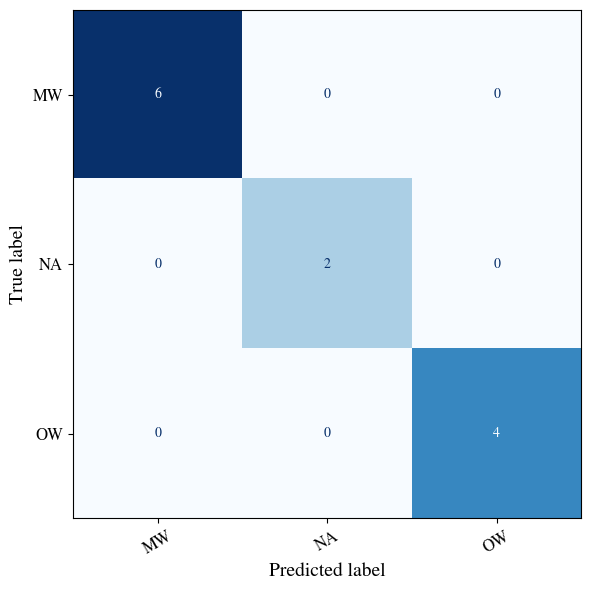

In [28]:
best_material_model = clone(material_models[best_material_name])
best_material_model.fit(X_train_mat, y_train_mat)

best_material_pred = best_material_model.predict(X_test_mat)

material_labels = list(range(len(material_encoder.classes_)))
material_class_names = [str(x) for x in material_encoder.classes_]

test_material_accuracy = accuracy_score(y_test_mat, best_material_pred)
test_material_bal_accuracy = balanced_accuracy_score(y_test_mat, best_material_pred)
test_material_f1_macro = f1_score(y_test_mat, best_material_pred, average="macro")

print("=== MATERIAL TEST RESULTS ===")
print(f"Accuracy:          {test_material_accuracy:.4f}")
print(f"Balanced accuracy: {test_material_bal_accuracy:.4f}")
print(f"Macro F1:          {test_material_f1_macro:.4f}")

print("\n=== MATERIAL CLASSIFICATION REPORT ===")
print(
    classification_report(
        y_test_mat,
        best_material_pred,
        labels=material_labels,
        target_names=material_class_names,
        zero_division=0
    )
)

cm_mat = confusion_matrix(
    y_test_mat,
    best_material_pred,
    labels=material_labels
)

disp_mat = ConfusionMatrixDisplay(
    confusion_matrix=cm_mat,
    display_labels=material_class_names
)

fig, ax = plt.subplots(figsize=(6, 6))
disp_mat.plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)

ax.set_title(f"")
ax.tick_params(axis="x", rotation=30)

fig.tight_layout()
save_pdf(fig, "fig01_confusion_matrix_material")
plt.show()


/usr/local/lib/python3.13/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
5 fits failed out of a total of 25.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.13/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "/usr/local/lib/python3.13/dist-packages/imblearn/pipeline.py", line 514, in fit
    Xt, yt = self._fit(X, y, routed_params

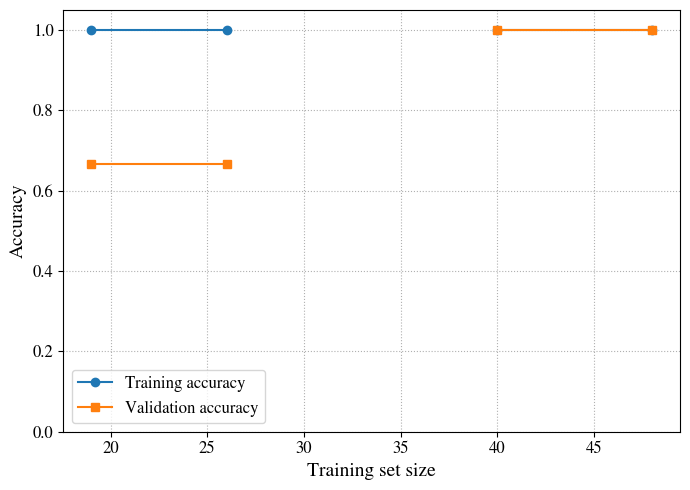

In [29]:
cv_curve_material = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

train_sizes, train_scores, val_scores = learning_curve(
    clone(material_models[best_material_name]),
    X_material,
    y_material_enc,
    cv=cv_curve_material,
    scoring="accuracy",
    n_jobs=-1,
    train_sizes=np.linspace(0.4, 1.0, 5),
    error_score=np.nan
)

train_mean = np.nanmean(train_scores, axis=1)
train_std = np.nanstd(train_scores, axis=1)
val_mean = np.nanmean(val_scores, axis=1)
val_std = np.nanstd(val_scores, axis=1)

fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(train_sizes, train_mean, marker="o", label="Training accuracy")
ax.plot(train_sizes, val_mean, marker="s", label="Validation accuracy")

ax.fill_between(
    train_sizes,
    train_mean - train_std,
    train_mean + train_std,
    alpha=0.2
)

ax.fill_between(
    train_sizes,
    val_mean - val_std,
    val_mean + val_std,
    alpha=0.2
)

ax.set_xlabel("Training set size")
ax.set_ylabel("Accuracy")
ax.set_title(f"")
ax.set_ylim(0, 1.05)
ax.grid(True, linestyle=":")
ax.legend()

fig.tight_layout()
save_pdf(fig, "fig02_learning_curve_material")
plt.show()


In [30]:
def train_percentage_classifiers(
    df_sub,
    material_name
):
    """
    Train the second-stage classifiers used to identify the
    additive-percentage class for one material family.
    """

    X = df_sub[FEATURES].copy()
    y = df_sub["percentage"].copy()

    pct_encoder = LabelEncoder()
    y_enc = pct_encoder.fit_transform(y)

    class_counts = (
        pd.Series(y_enc)
        .value_counts()
        .sort_index()
    )

    min_class_count = int(
        class_counts.min()
    )

    print(
        f"\n=== {material_name}: CLASS COUNTS ==="
    )

    for class_index, count in class_counts.items():

        original_label = (
            pct_encoder.inverse_transform(
                [class_index]
            )[0]
        )

        print(
            f"Class {original_label}: {count}"
        )

    if min_class_count < 2:
        raise ValueError(
            f"Material {material_name}: at least one "
            "percentage class contains fewer than "
            "two observations."
        )

    # Specimen-wise split retained as a within-domain reference.
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y_enc,
        test_size=0.2,
        random_state=42,
        stratify=y_enc
    )

    train_class_counts = (
        pd.Series(y_train)
        .value_counts()
    )

    min_train_class_count = int(
        train_class_counts.min()
    )

    if min_train_class_count < 2:
        raise ValueError(
            f"Material {material_name}: after the "
            "train/test split, at least one class "
            "contains fewer than two training samples."
        )

    n_splits_safe = min(
        5,
        min_train_class_count
    )

    # SMOTE uses fewer neighbors than the smallest class
    # available inside the training subset.
    smote_k = max(
        1,
        min(
            3,
            min_train_class_count - 1
        )
    )

    print(
        "Selected SMOTE k_neighbors:",
        smote_k
    )

    classifiers = {
        "RandomForestClassifier": ImbPipeline([
            (
                "smote",
                SMOTE(
                    random_state=42,
                    k_neighbors=smote_k
                )
            ),
            (
                "model",
                RandomForestClassifier(
                    n_estimators=200,
                    max_depth=5,
                    min_samples_leaf=2,
                    class_weight="balanced",
                    random_state=42
                )
            )
        ]),

        "LogisticRegression": ImbPipeline([
            (
                "scaler",
                StandardScaler()
            ),
            (
                "smote",
                SMOTE(
                    random_state=42,
                    k_neighbors=smote_k
                )
            ),
            (
                "model",
                LogisticRegression(
                    max_iter=3000,
                    class_weight="balanced",
                    random_state=42
                )
            )
        ]),

        "SVC": ImbPipeline([
            (
                "scaler",
                StandardScaler()
            ),
            (
                "smote",
                SMOTE(
                    random_state=42,
                    k_neighbors=smote_k
                )
            ),
            (
                "model",
                SVC(
                    probability=True,
                    class_weight="balanced",
                    random_state=42
                )
            )
        ])
    }

    cv = StratifiedKFold(
        n_splits=n_splits_safe,
        shuffle=True,
        random_state=42
    )

    rows = []

    best_name = None
    best_score = -np.inf

    for classifier_name, base_model in classifiers.items():

        classifier = clone(base_model)

        cv_results = cross_validate(
            classifier,
            X_train,
            y_train,
            cv=cv,
            scoring={
                "accuracy": "accuracy",
                "balanced_accuracy":
                    "balanced_accuracy",
                "f1_macro": "f1_macro"
            },
            return_train_score=True,
            n_jobs=-1,
            error_score=np.nan
        )

        row = {
            "classifier":
                classifier_name,

            "cv_train_accuracy_mean":
                np.nanmean(
                    cv_results["train_accuracy"]
                ),

            "cv_val_accuracy_mean":
                np.nanmean(
                    cv_results["test_accuracy"]
                ),

            "cv_val_accuracy_std":
                np.nanstd(
                    cv_results["test_accuracy"]
                ),

            "cv_val_bal_accuracy_mean":
                np.nanmean(
                    cv_results[
                        "test_balanced_accuracy"
                    ]
                ),

            "cv_val_f1_macro_mean":
                np.nanmean(
                    cv_results["test_f1_macro"]
                ),

            "cv_gap_mean":
                np.nanmean(
                    cv_results["train_accuracy"]
                    - cv_results["test_accuracy"]
                )
        }

        rows.append(row)

        score_for_selection = row[
            "cv_val_f1_macro_mean"
        ]

        if (
            not np.isnan(score_for_selection)
            and score_for_selection > best_score
        ):
            best_score = score_for_selection
            best_name = classifier_name

    results_df = (
        pd.DataFrame(rows)
        .sort_values(
            [
                "cv_val_f1_macro_mean",
                "cv_val_bal_accuracy_mean",
                "cv_val_accuracy_mean"
            ],
            ascending=False
        )
        .reset_index(drop=True)
    )

    trained_models = {}

    for classifier_name, base_model in classifiers.items():

        classifier = clone(base_model)

        classifier.fit(
            X_train,
            y_train
        )

        trained_models[
            classifier_name
        ] = classifier

    best_model = trained_models[
        best_name
    ]

    y_test_pred = best_model.predict(
        X_test
    )

    percentage_labels = list(
        range(
            len(pct_encoder.classes_)
        )
    )

    percentage_class_names = [
        str(value)
        for value in pct_encoder.classes_
    ]

    test_accuracy = accuracy_score(
        y_test,
        y_test_pred
    )

    test_bal_accuracy = balanced_accuracy_score(
        y_test,
        y_test_pred
    )

    test_f1_macro = f1_score(
        y_test,
        y_test_pred,
        average="macro"
    )

    print(
        f"\n=== PERCENTAGE CLASSIFICATION: "
        f"{material_name} ==="
    )

    print(
        "Best classifier:",
        best_name
    )

    print(
        f"CV folds used: "
        f"{n_splits_safe}"
    )

    print(
        f"Test accuracy: "
        f"{test_accuracy:.4f}"
    )

    print(
        f"Test balanced accuracy: "
        f"{test_bal_accuracy:.4f}"
    )

    print(
        f"Test macro F1: "
        f"{test_f1_macro:.4f}"
    )

    print("\nClassification report:")

    print(
        classification_report(
            y_test,
            y_test_pred,
            labels=percentage_labels,
            target_names=percentage_class_names,
            zero_division=0
        )
    )

    confusion_matrix_values = confusion_matrix(
        y_test,
        y_test_pred,
        labels=percentage_labels
    )

    display_matrix = ConfusionMatrixDisplay(
        confusion_matrix=
            confusion_matrix_values,
        display_labels=
            percentage_class_names
    )

    fig, ax = plt.subplots(
        figsize=(6, 6)
    )

    display_matrix.plot(
        ax=ax,
        cmap="Blues",
        values_format="d",
        colorbar=False
    )

    ax.set_title("")
    ax.tick_params(
        axis="x",
        rotation=30
    )

    fig.tight_layout()

    save_pdf(
        fig,
        "fig03_confusion_matrix_percentage_"
        f"{material_name.lower()}"
    )

    plt.show()

    return {
        "material_name":
            material_name,

        "X":
            X,

        "y":
            y,

        "encoder":
            pct_encoder,

        "X_train":
            X_train,

        "X_test":
            X_test,

        "y_train":
            y_train,

        "y_test":
            y_test,

        "classifiers":
            classifiers,

        "trained_models":
            trained_models,

        "best_name":
            best_name,

        "best_model":
            best_model,

        "best_test_pred":
            y_test_pred,

        "results_df":
            results_df,

        "test_accuracy":
            test_accuracy,

        "test_bal_accuracy":
            test_bal_accuracy,

        "test_f1_macro":
            test_f1_macro,

        "n_splits_used":
            n_splits_safe,

        "smote_k_neighbors":
            smote_k,
    }

In [12]:
df_MW = df[df["material"] == "MW"].copy()
df_OW = df[df["material"] == "OW"].copy()
df_NA = df[df["material"] == "NA"].copy()

print("MW shape:", df_MW.shape)
print("OW shape:", df_OW.shape)
print("NA shape:", df_NA.shape)

print("\nMW percentage classes:", sorted(df_MW["percentage"].unique()))
print("OW percentage classes:", sorted(df_OW["percentage"].unique()))
print("NA percentage classes:", sorted(df_NA["percentage"].unique()))

MW shape: (30, 5)
OW shape: (20, 5)
NA shape: (10, 5)

MW percentage classes: [np.int64(10), np.int64(20), np.int64(30)]
OW percentage classes: [np.int64(10), np.int64(20)]
NA percentage classes: [np.int64(0)]



=== MW: CLASS COUNTS ===
Class 10: 10
Class 20: 10
Class 30: 10
Selected SMOTE k_neighbors: 3

=== PERCENTAGE CLASSIFICATION: MW ===
Best classifier: RandomForestClassifier
CV folds used: 5
Test accuracy: 1.0000
Test balanced accuracy: 1.0000
Test macro F1: 1.0000

Classification report:
              precision    recall  f1-score   support

          10       1.00      1.00      1.00         2
          20       1.00      1.00      1.00         2
          30       1.00      1.00      1.00         2

    accuracy                           1.00         6
   macro avg       1.00      1.00      1.00         6
weighted avg       1.00      1.00      1.00         6



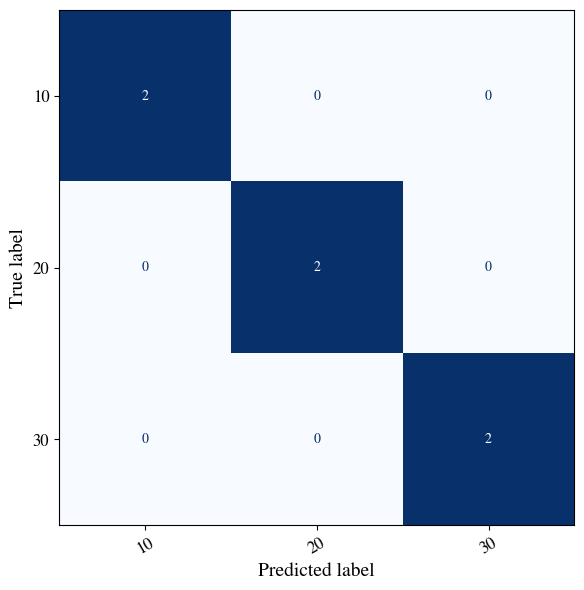


=== OW: CLASS COUNTS ===
Class 10: 10
Class 20: 10
Selected SMOTE k_neighbors: 3

=== PERCENTAGE CLASSIFICATION: OW ===
Best classifier: RandomForestClassifier
CV folds used: 5
Test accuracy: 1.0000
Test balanced accuracy: 1.0000
Test macro F1: 1.0000

Classification report:
              precision    recall  f1-score   support

          10       1.00      1.00      1.00         2
          20       1.00      1.00      1.00         2

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4



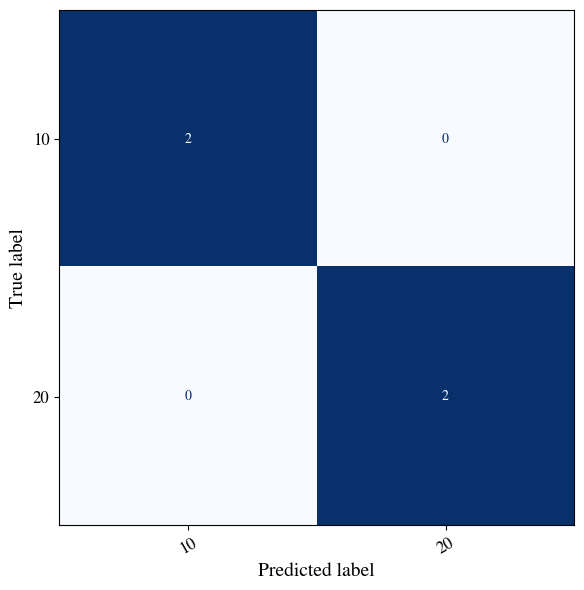

In [31]:
mw_percentage_system = train_percentage_classifiers(df_MW, "MW")
ow_percentage_system = train_percentage_classifiers(df_OW, "OW")

In [14]:
print("=== MW PERCENTAGE CLASSIFICATION RESULTS ===")
display(mw_percentage_system["results_df"])

print("\n=== OW PERCENTAGE CLASSIFICATION RESULTS ===")
display(ow_percentage_system["results_df"])

=== MW PERCENTAGE CLASSIFICATION RESULTS ===


,classifier,cv_train_accuracy_mean,cv_val_accuracy_mean,cv_val_accuracy_std,cv_val_bal_accuracy_mean,cv_val_f1_macro_mean,cv_gap_mean
0,RandomForestClassifier,1.0,1.0,0.0,1.0,1.0,0.0
1,LogisticRegression,1.0,1.0,0.0,1.0,1.0,0.0
2,SVC,1.0,1.0,0.0,1.0,1.0,0.0



=== OW PERCENTAGE CLASSIFICATION RESULTS ===


,classifier,cv_train_accuracy_mean,cv_val_accuracy_mean,cv_val_accuracy_std,cv_val_bal_accuracy_mean,cv_val_f1_macro_mean,cv_gap_mean
0,RandomForestClassifier,1.0,1.0,0.0,1.0,1.0,0.0
1,LogisticRegression,1.0,1.0,0.0,1.0,1.0,0.0
2,SVC,1.0,1.0,0.0,1.0,1.0,0.0


In [32]:
from sklearn.model_selection import StratifiedKFold, cross_validate
import numpy as np
import pandas as pd

def check_classification_overfitting(system_name, pct_system):

    X_train = pct_system["X_train"]
    y_train = pct_system["y_train"]

    best_name = pct_system["best_name"]
    best_model = clone(pct_system["trained_models"][best_name])

    min_train_class_count = int(pd.Series(y_train).value_counts().min())
    n_splits_safe = min(5, min_train_class_count)

    if n_splits_safe < 2:
        raise ValueError(
            f"{system_name}: at least one class has fewer than 2 train samples."
        )

    cv = StratifiedKFold(
        n_splits=n_splits_safe,
        shuffle=True,
        random_state=42
    )

    scores = cross_validate(
        best_model,
        X_train,
        y_train,
        cv=cv,
        scoring={
            "accuracy": "accuracy",
            "f1_macro": "f1_macro",
            "balanced_accuracy": "balanced_accuracy"
        },
        return_train_score=True,
        n_jobs=-1
    )

    # Mean training and validation scores.
    train_acc_mean = np.mean(scores["train_accuracy"])
    val_acc_mean = np.mean(scores["test_accuracy"])

    train_f1_mean = np.mean(scores["train_f1_macro"])
    val_f1_mean = np.mean(scores["test_f1_macro"])

    # Absolute and relative generalization gaps.
    acc_gap_abs = train_acc_mean - val_acc_mean
    acc_gap_rel = acc_gap_abs / train_acc_mean if train_acc_mean > 0 else np.nan

    f1_gap_abs = np.mean(scores["train_f1_macro"] - scores["test_f1_macro"])
    f1_gap_rel = f1_gap_abs / val_f1_mean if val_f1_mean > 0 else np.nan

    # Relative variability of the validation F1 score.
    val_f1_std = np.std(scores["test_f1_macro"])
    stability = val_f1_std / val_f1_mean if val_f1_mean > 0 else np.nan

    # Qualitative overfitting indicator based on the relative F1 gap.
    if f1_gap_rel < 0.10:
        risk = "low"
    elif f1_gap_rel < 0.25:
        risk = "moderate"
    else:
        risk = "high"

    return {
        "system": system_name,
        "best_classifier": best_name,
        "cv_folds_used": n_splits_safe,

        "train_acc_mean": train_acc_mean,
        "val_acc_mean": val_acc_mean,

        "train_f1_mean": train_f1_mean,
        "val_f1_mean": val_f1_mean,

        "acc_gap_abs": acc_gap_abs,
        "acc_gap_rel": acc_gap_rel,

        "f1_gap_abs": f1_gap_abs,
        "f1_gap_rel": f1_gap_rel,

        "val_f1_std": val_f1_std,
        "stability": stability,

        "overfitting_risk": risk
    }


In [33]:
def print_overfitting_report(report):
    print(f"System: {report['system']}")
    print(f"Best model: {report['best_classifier']}")
    print(f"Train ACC: {report['train_acc_mean']:.3f}")
    print(f"Val ACC:   {report['val_acc_mean']:.3f}")
    print(f"Train F1:  {report['train_f1_mean']:.3f}")
    print(f"Val F1:    {report['val_f1_mean']:.3f}")
    print(f"ACC gap:   {report['acc_gap_abs']:.3f} ({report['acc_gap_rel']*100:.1f}%)")
    print(f"F1 gap:    {report['f1_gap_abs']:.3f} ({report['f1_gap_rel']*100:.1f}%)")
    print(f"Stability: {report['stability']:.3f}")
    print(f"Risk:      {report['overfitting_risk']}")
    print("-" * 40)


# Check overfitting for percentage classification models
mw_overfit_df = check_classification_overfitting("MW", mw_percentage_system)
ow_overfit_df = check_classification_overfitting("OW", ow_percentage_system)


print("=== OVERFITTING CHECK - MW PERCENTAGE ===")
print_overfitting_report(mw_overfit_df)

print("=== OVERFITTING CHECK - OW PERCENTAGE ===")
print_overfitting_report(ow_overfit_df)

=== OVERFITTING CHECK - MW PERCENTAGE ===
System: MW
Best model: RandomForestClassifier
Train ACC: 1.000
Val ACC:   1.000
Train F1:  1.000
Val F1:    1.000
ACC gap:   0.000 (0.0%)
F1 gap:    0.000 (0.0%)
Stability: 0.000
Risk:      low
----------------------------------------
=== OVERFITTING CHECK - OW PERCENTAGE ===
System: OW
Best model: RandomForestClassifier
Train ACC: 1.000
Val ACC:   1.000
Train F1:  1.000
Val F1:    1.000
ACC gap:   0.000 (0.0%)
F1 gap:    0.000 (0.0%)
Stability: 0.000
Risk:      low
----------------------------------------


In [34]:
def run_percentage_cv(df_sub, pct_system, title):
    X = df_sub[["flexural_modulus", "flexural_strength", "strain_at_break"]].copy()
    y = df_sub["percentage"].copy()

    encoder = LabelEncoder()
    y_enc = encoder.fit_transform(y)

    n_splits_safe = pct_system["n_splits_used"]

    cv = StratifiedKFold(
        n_splits=n_splits_safe,
        shuffle=True,
        random_state=42
    )

    best_name = pct_system["best_name"]
    best_pipeline = clone(pct_system["classifiers"][best_name])

    cv_results = cross_validate(
        best_pipeline,
        X,
        y_enc,
        cv=cv,
        scoring={
            "accuracy": "accuracy",
            "balanced_accuracy": "balanced_accuracy",
            "f1_macro": "f1_macro"
        },
        return_train_score=True,
        n_jobs=-1,
        error_score=np.nan
    )

    cv_summary = pd.DataFrame({
        "fold": range(1, n_splits_safe + 1),
        "train_accuracy": cv_results["train_accuracy"],
        "val_accuracy": cv_results["test_accuracy"],
        "val_bal_accuracy": cv_results["test_balanced_accuracy"],
        "val_f1_macro": cv_results["test_f1_macro"]
    })

    print(f"=== CROSS-VALIDATION - {title} ===")
    display(cv_summary)
    print("Mean train accuracy:", np.nanmean(cv_summary["train_accuracy"]))
    print("Mean val accuracy:  ", np.nanmean(cv_summary["val_accuracy"]))
    print("Mean val bal acc:   ", np.nanmean(cv_summary["val_bal_accuracy"]))
    print("Mean val macro F1:  ", np.nanmean(cv_summary["val_f1_macro"]))
    print("Mean gap:           ", np.nanmean(cv_summary["train_accuracy"] - cv_summary["val_accuracy"]))

In [35]:
run_percentage_cv(df_MW, mw_percentage_system, "MW")
run_percentage_cv(df_OW, ow_percentage_system, "OW")

=== CROSS-VALIDATION - MW ===


,fold,train_accuracy,val_accuracy,val_bal_accuracy,val_f1_macro
0,1,1.0,1.0,1.0,1.0
1,2,1.0,1.0,1.0,1.0
2,3,1.0,1.0,1.0,1.0
3,4,1.0,1.0,1.0,1.0
4,5,1.0,1.0,1.0,1.0


Mean train accuracy: 1.0
Mean val accuracy:   1.0
Mean val bal acc:    1.0
Mean val macro F1:   1.0
Mean gap:            0.0
=== CROSS-VALIDATION - OW ===


,fold,train_accuracy,val_accuracy,val_bal_accuracy,val_f1_macro
0,1,1.0,1.0,1.0,1.0
1,2,1.0,1.0,1.0,1.0
2,3,1.0,1.0,1.0,1.0
3,4,1.0,1.0,1.0,1.0
4,5,1.0,1.0,1.0,1.0


Mean train accuracy: 1.0
Mean val accuracy:   1.0
Mean val bal acc:    1.0
Mean val macro F1:   1.0
Mean gap:            0.0


In [36]:
def plot_percentage_learning_curve(df_sub, pct_system, title, filename):
    X = df_sub[["flexural_modulus", "flexural_strength", "strain_at_break"]].copy()
    y = df_sub["percentage"].copy()

    encoder = LabelEncoder()
    y_enc = encoder.fit_transform(y)

    best_name = pct_system["best_name"]
    best_pipeline = clone(pct_system["classifiers"][best_name])

    n_splits_safe = pct_system["n_splits_used"]

    cv_curve = StratifiedKFold(
        n_splits=n_splits_safe,
        shuffle=True,
        random_state=42
    )

    train_sizes, train_scores, val_scores = learning_curve(
        best_pipeline,
        X,
        y_enc,
        cv=cv_curve,
        scoring="accuracy",
        n_jobs=-1,
        train_sizes=np.linspace(0.4, 1.0, 5),
        error_score=np.nan
    )

    train_mean = np.nanmean(train_scores, axis=1)
    train_std = np.nanstd(train_scores, axis=1)
    val_mean = np.nanmean(val_scores, axis=1)
    val_std = np.nanstd(val_scores, axis=1)

    fig, ax = plt.subplots(figsize=(7, 5))

    ax.plot(train_sizes, train_mean, marker="o", label="Training accuracy")
    ax.plot(train_sizes, val_mean, marker="s", label="Validation accuracy")

    ax.fill_between(
        train_sizes,
        train_mean - train_std,
        train_mean + train_std,
        alpha=0.2
    )

    ax.fill_between(
        train_sizes,
        val_mean - val_std,
        val_mean + val_std,
        alpha=0.2
    )

    ax.set_xlabel("Training set size")
    ax.set_ylabel("Accuracy")
    ax.set_title(f"")
    ax.set_ylim(0, 1.05)
    ax.grid(True, linestyle=":")
    ax.legend()

    fig.tight_layout()
    save_pdf(fig, filename)
    plt.show()


/usr/local/lib/python3.13/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
5 fits failed out of a total of 25.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.13/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "/usr/local/lib/python3.13/dist-packages/imblearn/pipeline.py", line 514, in fit
    Xt, yt = self._fit(X, y, routed_params

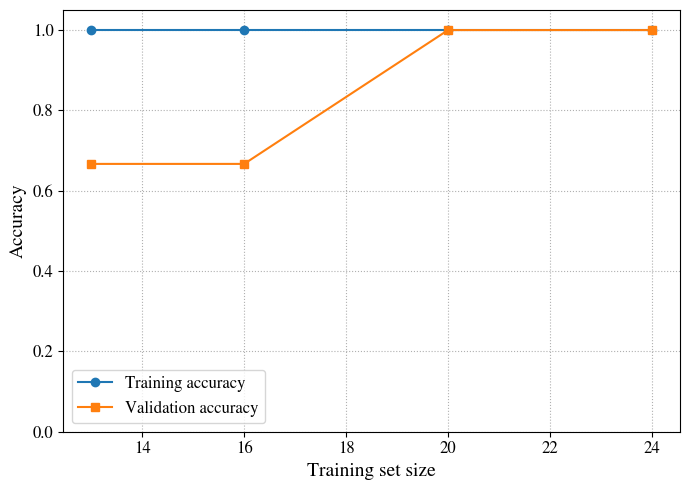

/usr/local/lib/python3.13/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
15 fits failed out of a total of 25.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
10 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.13/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "/usr/local/lib/python3.13/dist-packages/imblearn/pipeline.py", line 514, in fit
    Xt, yt = self._fit(X, y, routed_para

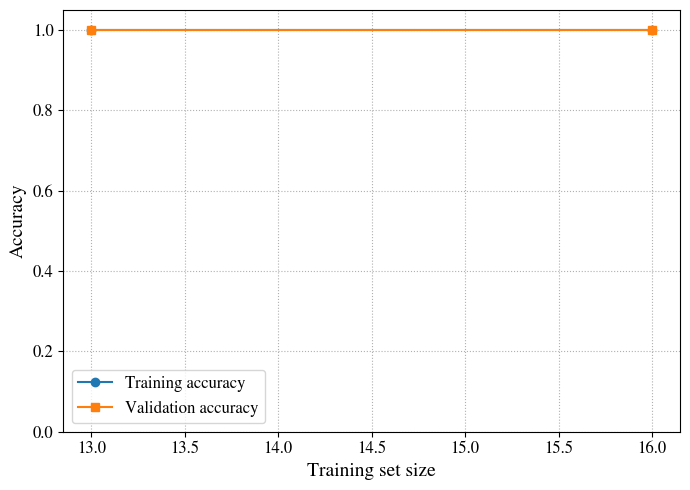

In [37]:
plot_percentage_learning_curve(
    df_MW,
    mw_percentage_system,
    "MW",
    "fig04_learning_curve_percentage_mw"
)

plot_percentage_learning_curve(
    df_OW,
    ow_percentage_system,
    "OW",
    "fig05_learning_curve_percentage_ow"
)


## Formulation-wise limitation of the second classification stage

Strategy B is a closed-set classification framework. If an entire
percentage level is excluded from training, the corresponding class is
no longer available to the classifier and therefore cannot be recovered
as an exact prediction.

The following ordered-degradation analysis does not report this
condition as successful prediction. Instead, it evaluates whether
specimens belonging to the excluded formulation are assigned to the
nearest percentage class remaining in the training dataset.

In [38]:
# Ordered-degradation analysis for the second classification stage.
#
# A percentage class that is completely excluded from training
# cannot be predicted by a closed-set classifier. This analysis
# evaluates whether the excluded specimens are assigned to the
# nearest percentage level remaining in the training dataset.

ordered_degradation_rows = []

percentage_systems = {
    "MW": mw_percentage_system,
    "OW": ow_percentage_system,
}

family_datasets = {
    "MW": df_MW,
    "OW": df_OW,
}

for family_name, df_family in family_datasets.items():

    percentage_levels = sorted(
        df_family[
            "percentage"
        ]
        .astype(float)
        .unique()
    )

    for held_level in percentage_levels:

        train_data = df_family[
            df_family[
                "percentage"
            ].astype(float) != held_level
        ].copy()

        test_data = df_family[
            df_family[
                "percentage"
            ].astype(float) == held_level
        ].copy()

        available_levels = sorted(
            train_data[
                "percentage"
            ]
            .astype(float)
            .unique()
        )

        distances_from_held_level = {
            available_level:
                abs(
                    available_level
                    - held_level
                )
            for available_level
            in available_levels
        }

        minimum_distance = min(
            distances_from_held_level.values()
        )

        nearest_available_levels = [
            available_level
            for (
                available_level,
                distance
            )
            in distances_from_held_level.items()
            if distance == minimum_distance
        ]

        # When only one percentage class remains, as occurs
        # for OW, the prediction is necessarily that class.
        if len(available_levels) == 1:

            predictions = np.repeat(
                available_levels[0],
                len(test_data)
            )

            model_used = (
                "single remaining class"
            )

        else:

            ordered_model = clone(
                percentage_systems[
                    family_name
                ][
                    "classifiers"
                ][
                    "RandomForestClassifier"
                ]
            )

            ordered_model.fit(
                train_data[FEATURES],
                train_data[
                    "percentage"
                ].astype(str)
            )

            predictions = (
                ordered_model
                .predict(
                    test_data[FEATURES]
                )
                .astype(float)
            )

            model_used = (
                "RandomForestClassifier"
            )

        predicted_distribution = (
            pd.Series(predictions)
            .value_counts()
            .sort_index()
            .to_dict()
        )

        share_on_nearest_class = float(
            np.mean(
                np.isin(
                    predictions,
                    nearest_available_levels
                )
            )
        )

        ordered_degradation_rows.append({
            "material_family":
                family_name,

            "held_out_percentage_wt":
                held_level,

            "available_training_classes_wt":
                str(available_levels),

            "predicted_distribution":
                str(predicted_distribution),

            "nearest_available_class_wt":
                str(nearest_available_levels),

            "share_assigned_to_nearest_class":
                share_on_nearest_class,

            "model_used":
                model_used,
        })

ordered_degradation_df = pd.DataFrame(
    ordered_degradation_rows
)

print(
    "=== STRATEGY B: ORDERED DEGRADATION "
    "UNDER FORMULATION EXCLUSION ==="
)

display(
    ordered_degradation_df
)

print(
    "\nThe excluded percentage class is absent from "
    "the training dataset. Assignment to the nearest "
    "remaining class is interpreted as ordered "
    "degradation and not as successful prediction "
    "of an unseen concentration class."
)

=== STRATEGY B: ORDERED DEGRADATION UNDER FORMULATION EXCLUSION ===


,material_family,held_out_percentage_wt,available_training_classes_wt,predicted_distribution,nearest_available_class_wt,share_assigned_to_nearest_class,model_used
0,MW,10.0,"[np.float64(20.0), np.float64(30.0)]",{20.0: 10},[np.float64(20.0)],1.0,RandomForestClassifier
1,MW,20.0,"[np.float64(10.0), np.float64(30.0)]","{10.0: 8, 30.0: 2}","[np.float64(10.0), np.float64(30.0)]",1.0,RandomForestClassifier
2,MW,30.0,"[np.float64(10.0), np.float64(20.0)]",{20.0: 10},[np.float64(20.0)],1.0,RandomForestClassifier
3,OW,10.0,[np.float64(20.0)],{20.0: 10},[np.float64(20.0)],1.0,single remaining class
4,OW,20.0,[np.float64(10.0)],{10.0: 10},[np.float64(10.0)],1.0,single remaining class



The excluded percentage class is absent from the training dataset. Assignment to the nearest remaining class is interpreted as ordered degradation and not as successful prediction of an unseen concentration class.


In [39]:
# Refit the selected classifiers on all available observations.
#
# Model selection and performance assessment were performed above.
# The final models used for inverse-design queries are now fitted
# to the complete available dataset.

final_material_model = clone(
    material_models[best_material_name]
)

final_material_model.fit(
    X_material,
    y_material_enc
)


def refit_final_percentage_classifier(
    df_sub,
    percentage_system
):
    """Refit the selected percentage classifier on all available data."""

    X_full = df_sub[FEATURES].copy()
    y_full = df_sub["percentage"].copy()

    percentage_encoder = percentage_system[
        "encoder"
    ]

    y_full_encoded = percentage_encoder.transform(
        y_full
    )

    selected_classifier_name = percentage_system[
        "best_name"
    ]

    final_model = clone(
        percentage_system[
            "classifiers"
        ][selected_classifier_name]
    )

    final_model.fit(
        X_full,
        y_full_encoded
    )

    return {
        "model": final_model,
        "encoder": percentage_encoder,
        "classifier_name":
            selected_classifier_name,
    }


final_percentage_models = {
    "MW": refit_final_percentage_classifier(
        df_MW,
        mw_percentage_system
    ),

    "OW": refit_final_percentage_classifier(
        df_OW,
        ow_percentage_system
    ),
}

print(
    "Final material-family classifier:",
    best_material_name
)

print(
    "Final MW percentage classifier:",
    final_percentage_models[
        "MW"
    ][
        "classifier_name"
    ]
)

print(
    "Final OW percentage classifier:",
    final_percentage_models[
        "OW"
    ][
        "classifier_name"
    ]
)

Final material-family classifier: SVC
Final MW percentage classifier: RandomForestClassifier
Final OW percentage classifier: RandomForestClassifier


In [40]:
def predict_material_and_percentage_classification(
    flexural_modulus,
    flexural_strength,
    strain_at_break
):
    """
    Identify the material family and the corresponding discrete
    additive-percentage class from target mechanical requirements.

    The inputs represent performance requirements specified a priori
    by the designer and not measurements obtained from an unknown
    specimen.
    """

    target_requirements = {
        "flexural_modulus":
            float(flexural_modulus),

        "flexural_strength":
            float(flexural_strength),

        "strain_at_break":
            float(strain_at_break),
    }

    X_input = pd.DataFrame(
        [target_requirements]
    )[FEATURES]

    print(
        "\n=== TARGET MECHANICAL REQUIREMENTS ==="
    )

    display(X_input)

    # First classification stage: material family.
    predicted_material_encoded = (
        final_material_model.predict(
            X_input
        )[0]
    )

    predicted_material = (
        material_encoder.inverse_transform(
            [predicted_material_encoded]
        )[0]
    )

    print(
        "\n=== MATERIAL-FAMILY CLASSIFICATION ==="
    )

    print(
        "Selected classifier:",
        best_material_name
    )

    print(
        "Recommended material family:",
        predicted_material
    )

    if predicted_material == "NA":

        print(
            "Recommended additive percentage: "
            "0 wt.%"
        )

        return pd.DataFrame([{
            "target_flexural_modulus":
                flexural_modulus,

            "target_flexural_strength":
                flexural_strength,

            "target_strain_at_break":
                strain_at_break,

            "recommended_material":
                "NA",

            "recommended_percentage_wt":
                0.0,

            "material_classifier":
                best_material_name,

            "percentage_classifier":
                "constant neat-PLA class",

            "prediction_type":
                "experimentally available class",
        }])

    # Second classification stage: percentage class.
    selected_percentage_system = (
        final_percentage_models[
            predicted_material
        ]
    )

    percentage_model = (
        selected_percentage_system[
            "model"
        ]
    )

    percentage_encoder = (
        selected_percentage_system[
            "encoder"
        ]
    )

    predicted_percentage_encoded = (
        percentage_model.predict(
            X_input
        )[0]
    )

    predicted_percentage = (
        percentage_encoder.inverse_transform(
            [predicted_percentage_encoded]
        )[0]
    )

    percentage_classifier_name = (
        selected_percentage_system[
            "classifier_name"
        ]
    )

    print(
        "\n=== PERCENTAGE-CLASS CLASSIFICATION ==="
    )

    print(
        "Selected classifier:",
        percentage_classifier_name
    )

    print(
        "Recommended additive percentage:",
        f"{predicted_percentage} wt.%"
    )

    print(
        "\nThe recommended percentage corresponds "
        "to an experimentally available class. "
        "Strategy B cannot return intermediate "
        "percentage values."
    )

    return pd.DataFrame([{
        "target_flexural_modulus":
            flexural_modulus,

        "target_flexural_strength":
            flexural_strength,

        "target_strain_at_break":
            strain_at_break,

        "recommended_material":
            predicted_material,

        "recommended_percentage_wt":
            float(predicted_percentage),

        "material_classifier":
            best_material_name,

        "percentage_classifier":
            percentage_classifier_name,

        "prediction_type":
            "experimentally available class",
    }])

In [24]:
# Illustrative Strategy B queries.
#
# These inputs are target mechanical requirements specified a priori.
# Strategy B returns only percentage classes corresponding to
# experimentally characterized formulations.

strategy_b_queries = {
    "B1": {
        "flexural_modulus": 3.50,
        "flexural_strength": 70.0,
        "strain_at_break": 2.80,
    },

    "B2": {
        "flexural_modulus": 3.90,
        "flexural_strength": 58.0,
        "strain_at_break": 2.10,
    },

    "B3": {
        "flexural_modulus": 2.00,
        "flexural_strength": 38.0,
        "strain_at_break": 3.40,
    },
}

strategy_b_query_results = []

for query_name, query_values in strategy_b_queries.items():

    print("\n" + "=" * 78)
    print(query_name)
    print("=" * 78)

    query_result = (
        predict_material_and_percentage_classification(
            **query_values
        )
    )

    query_result.insert(
        0,
        "query",
        query_name
    )

    strategy_b_query_results.append(
        query_result
    )

strategy_b_queries_df = pd.concat(
    strategy_b_query_results,
    ignore_index=True
)

print(
    "\n=== STRATEGY B DESIGN QUERIES ==="
)

display(
    strategy_b_queries_df
)


B1

=== TARGET MECHANICAL REQUIREMENTS ===


,flexural_modulus,flexural_strength,strain_at_break
0,3.5,70.0,2.8



=== MATERIAL-FAMILY CLASSIFICATION ===
Selected classifier: LogisticRegression
Recommended material family: MW

=== PERCENTAGE-CLASS CLASSIFICATION ===
Selected classifier: RandomForestClassifier
Recommended additive percentage: 20 wt.%

The recommended percentage corresponds to an experimentally available class. Strategy B cannot return intermediate percentage values.

B2

=== TARGET MECHANICAL REQUIREMENTS ===


,flexural_modulus,flexural_strength,strain_at_break
0,3.9,58.0,2.1



=== MATERIAL-FAMILY CLASSIFICATION ===
Selected classifier: LogisticRegression
Recommended material family: MW

=== PERCENTAGE-CLASS CLASSIFICATION ===
Selected classifier: RandomForestClassifier
Recommended additive percentage: 30 wt.%

The recommended percentage corresponds to an experimentally available class. Strategy B cannot return intermediate percentage values.

B3

=== TARGET MECHANICAL REQUIREMENTS ===


,flexural_modulus,flexural_strength,strain_at_break
0,2.0,38.0,3.4



=== MATERIAL-FAMILY CLASSIFICATION ===
Selected classifier: LogisticRegression
Recommended material family: OW

=== PERCENTAGE-CLASS CLASSIFICATION ===
Selected classifier: RandomForestClassifier
Recommended additive percentage: 10 wt.%

The recommended percentage corresponds to an experimentally available class. Strategy B cannot return intermediate percentage values.

=== STRATEGY B DESIGN QUERIES ===


,query,target_flexural_modulus,target_flexural_strength,target_strain_at_break,recommended_material,recommended_percentage_wt,material_classifier,percentage_classifier,prediction_type
0,B1,3.5,70.0,2.8,MW,20.0,LogisticRegression,RandomForestClassifier,experimentally available class
1,B2,3.9,58.0,2.1,MW,30.0,LogisticRegression,RandomForestClassifier,experimentally available class
2,B3,2.0,38.0,3.4,OW,10.0,LogisticRegression,RandomForestClassifier,experimentally available class


In [41]:
# Export Strategy B result tables.

from pathlib import Path

RESULTS_DIR = Path("result_tables")
RESULTS_DIR.mkdir(exist_ok=True)

strategy_b_exports = {
    "strategyB_material_classification.csv":
        material_results_df,

    "strategyB_MW_percentage_classification.csv":
        mw_percentage_system["results_df"],

    "strategyB_OW_percentage_classification.csv":
        ow_percentage_system["results_df"],

    "strategyB_ordered_degradation.csv":
        ordered_degradation_df,

    "strategyB_design_queries.csv":
        strategy_b_queries_df,
}

for filename, table in strategy_b_exports.items():

    output_path = RESULTS_DIR / filename

    table.to_csv(
        output_path,
        index=False
    )

    print(
        f"Saved: {output_path} "
        f"({len(table)} rows)"
    )

Saved: result_tables/strategyB_material_classification.csv (3 rows)
Saved: result_tables/strategyB_MW_percentage_classification.csv (3 rows)
Saved: result_tables/strategyB_OW_percentage_classification.csv (3 rows)
Saved: result_tables/strategyB_ordered_degradation.csv (5 rows)
Saved: result_tables/strategyB_design_queries.csv (3 rows)


In [26]:
# Optional: create a zip archive of the generated PDF figures.
# This cell is safe for local/Jupyter execution and does not require Google Colab.

import shutil
from pathlib import Path

figures_dir = Path("figures_pdf")
if figures_dir.exists():
    shutil.make_archive("figures_pdf", "zip", figures_dir)
    print("Created figures_pdf.zip")
else:
    print("No figures_pdf folder found.")


Created figures_pdf.zip
